In [1]:
import json, requests, pprint
import pandas as pd

# please enter your appid here
APPID = '3741775b9523fb5654ad764de205b071'
# assume the location to be las vegas. You can also ask the user to enter the location
# The format of the location should be "cityName, 2-letter_country_code"
location = 'Las Vegas, NV, US'

# Function to get weather data from OpenWeatherMap API
def get_weather_data(endpoint, params):
    url = f'https://api.openweathermap.org/data/2.5/{endpoint}'
    params['q'] = location
    params['appid'] = APPID
    params['units'] = 'Imperial'
    response = requests.get(url, params=params)
    response.raise_for_status()
    return json.loads(response.text)

# Function to display current weather
def display_current_weather():
    weather_data = get_weather_data('weather', {})
    print('Current weather in', weather_data['name'])
    weather_sec = weather_data['weather'][0]['description']
    main_sec = weather_data['main']
    print(f"Description: {weather_sec}")
    print(f"Temperature: {main_sec['temp']}°F")
    print(f"Feels like: {main_sec['feels_like']}°F")
    print(f"Humidity: {main_sec['humidity']}%")

# Function to display forecast weather
def display_forecast_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    forecast_date = input("Enter the forecast date (YYYY-MM-DD): ")
    forecast_for_date = [f for f in forecast_data['list'] if f['dt_txt'].startswith(forecast_date)]
    if not forecast_for_date:
        print("No forecast data available for the given date.")
    else:
        avg_temp = sum(f['main']['temp'] for f in forecast_for_date) / len(forecast_for_date)
        avg_humidity = sum(f['main']['humidity'] for f in forecast_for_date) / len(forecast_for_date)
        avg_wind_speed = sum(f['wind']['speed'] for f in forecast_for_date) / len(forecast_for_date)
        print(f"\nForecast Weather Data for {forecast_date}")
        print(f"Average Temperature: {avg_temp:.2f}°F")
        print(f"Average Humidity: {avg_humidity:.2f}%")
        print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")

# Function to display historical weather
def display_historical_weather():
    print("Historical data is not directly available from the free OpenWeatherMap API.")
    # Note: Historical data requires a paid subscription and is typically fetched via different endpoints.

# Function to display monthly weather (5-day forecast data as a rough estimate)
def display_monthly_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    avg_temp = sum(f['main']['temp'] for f in forecast_data['list']) / len(forecast_data['list'])
    avg_humidity = sum(f['main']['humidity'] for f in forecast_data['list']) / len(forecast_data['list'])
    avg_wind_speed = sum(f['wind']['speed'] for f in forecast_data['list']) / len(forecast_data['list'])
    print(f"\nAverage Monthly Weather Estimate (Based on 5-Day Forecast)")
    print(f"Average Temperature: {avg_temp:.2f}°F")
    print(f"Average Humidity: {avg_humidity:.2f}%")
    print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")

# Main menu function to display options and link to weather dashboard
def main_menu():
    while True:
        print("\nWeather Dashboard Main Menu")
        print("1. Current Weather")
        print("2. Monthly Weather")
        print("3. Historical Weather")
        print("4. Forecast Weather")
        print("5. Exit")

        menu_input = input("Please enter menu selection (1 - 5): ")

        if menu_input == "1":
            display_current_weather()
        elif menu_input == "2":
            display_monthly_weather()
        elif menu_input == "3":
            display_historical_weather()
        elif menu_input == "4":
            display_forecast_weather()
        elif menu_input == "5":
            print("Exiting the Weather Dashboard.")
            break
        else:
            print("Invalid choice. Please try again.")

# Run the main menu
if __name__ == "__main__":
    main_menu()



Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  1


Current weather in Las Vegas
Description: overcast clouds
Temperature: 59.04°F
Feels like: 56.14°F
Humidity: 32%

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  2



Average Monthly Weather Estimate (Based on 5-Day Forecast)
Average Temperature: 50.21°F
Average Humidity: 20.70%
Average Wind Speed: 4.12 mph

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


...

Historical data is not directly available from the free OpenWeatherMap API.

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  4
Enter the forecast date (YYYY-MM-DD):  2024-11-28



Forecast Weather Data for 2024-11-28
Average Temperature: 48.75°F
Average Humidity: 28.38%
Average Wind Speed: 6.57 mph

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  5


Exiting the Weather Dashboard.


In [7]:
import json, requests, pprint
import pandas as pd

# please enter your appid here
APPID = '3741775b9523fb5654ad764de205b071'
# assume the location to be las vegas. You can also ask the user to enter the location
# The format of the location should be "cityName, 2-letter_country_code"
location = 'Las Vegas, NV, US'

# Load historical weather data
weather_data = pd.read_csv('Weather report (2019 -2024).csv', skiprows=1)

# Standardize column names
weather_data.columns = [
    "Date", "Max Temp (\u00b0F)", "Avg Temp (\u00b0F)", "Min Temp (\u00b0F)",
    "Max Dew Point (\u00b0F)", "Avg Dew Point (\u00b0F)", "Min Dew Point (\u00b0F)",
    "Max Humidity (%)", "Avg Humidity (%)", "Min Humidity (%)",
    "Max Wind Speed (mph)", "Avg Wind Speed (mph)", "Min Wind Speed (mph)",
    "Max Pressure (in)", "Avg Pressure (in)", "Min Pressure (in)",
    "Precipitation (in)"
]

# Fill missing values and ensure 'Date' is in datetime format
weather_data.fillna(0, inplace=True)
weather_data['Date'] = pd.to_datetime(weather_data['Date'], format="%m/%d/%y", errors='coerce')
weather_data = weather_data[weather_data['Date'].notna()]

# Convert numeric columns to proper types
numeric_columns = [
    "Max Temp (\u00b0F)", "Avg Temp (\u00b0F)", "Min Temp (\u00b0F)",
    "Max Dew Point (\u00b0F)", "Avg Dew Point (\u00b0F)", "Min Dew Point (\u00b0F)",
    "Max Humidity (%)", "Avg Humidity (%)", "Min Humidity (%)",
    "Max Wind Speed (mph)", "Avg Wind Speed (mph)", "Min Wind Speed (mph)",
    "Max Pressure (in)", "Avg Pressure (in)", "Min Pressure (in)",
    "Precipitation (in)"
]
weather_data[numeric_columns] = weather_data[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Function to get weather data from OpenWeatherMap API
def get_weather_data(endpoint, params):
    url = f'https://api.openweathermap.org/data/2.5/{endpoint}'
    params['q'] = location
    params['appid'] = APPID
    params['units'] = 'Imperial'
    response = requests.get(url, params=params)
    response.raise_for_status()
    return json.loads(response.text)

# Function to display current weather
def display_current_weather():
    weather_data = get_weather_data('weather', {})
    print('Current weather in', weather_data['name'])
    weather_sec = weather_data['weather'][0]['description']
    main_sec = weather_data['main']
    print(f"Description: {weather_sec}")
    print(f"Temperature: {main_sec['temp']}\u00b0F")
    print(f"Feels like: {main_sec['feels_like']}\u00b0F")
    print(f"Humidity: {main_sec['humidity']}%")

# Function to display forecast weather
def display_forecast_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    forecast_date = input("Enter the forecast date (YYYY-MM-DD): ")
    forecast_for_date = [f for f in forecast_data['list'] if f['dt_txt'].startswith(forecast_date)]
    if not forecast_for_date:
        print("No forecast data available for the given date.")
    else:
        avg_temp = sum(f['main']['temp'] for f in forecast_for_date) / len(forecast_for_date)
        avg_humidity = sum(f['main']['humidity'] for f in forecast_for_date) / len(forecast_for_date)
        avg_wind_speed = sum(f['wind']['speed'] for f in forecast_for_date) / len(forecast_for_date)
        print(f"\nForecast Weather Data for {forecast_date}")
        print(f"Average Temperature: {avg_temp:.2f}\u00b0F")
        print(f"Average Humidity: {avg_humidity:.2f}%")
        print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")

# Function to display historical weather
def display_historical_weather():
    try:
        start_date = pd.to_datetime(input("Enter the start date (YYYY-MM-DD): "))
        end_date = pd.to_datetime(input("Enter the end date (YYYY-MM-DD): "))
    except ValueError:
        print("Invalid date format. Please enter dates in the format YYYY-MM-DD.")
        return

    if (end_date - start_date).days > 7:
        print("Error: Maximum date range is 7 days.")
        return

    historical_data = weather_data[
        (weather_data['Date'] >= start_date) & (weather_data['Date'] <= end_date)
    ]
    if historical_data.empty:
        print("No historical data available for the given range.")
    else:
        avg_temp = pd.to_numeric(historical_data['Avg Temp (\u00b0F)'], errors='coerce').mean()
        avg_humidity = pd.to_numeric(historical_data['Avg Humidity (%)'], errors='coerce').mean()
        avg_wind_speed = pd.to_numeric(historical_data['Avg Wind Speed (mph)'], errors='coerce').mean()
        print(f"\nHistorical Weather Data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
        print(f"Average Temperature: {avg_temp:.2f}\u00b0F")
        print(f"Average Humidity: {avg_humidity:.2f}%")
        print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")

# Function to display monthly weather (5-day forecast data as a rough estimate)
def display_monthly_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    avg_temp = sum(f['main']['temp'] for f in forecast_data['list']) / len(forecast_data['list'])
    avg_humidity = sum(f['main']['humidity'] for f in forecast_data['list']) / len(forecast_data['list'])
    avg_wind_speed = sum(f['wind']['speed'] for f in forecast_data['list']) / len(forecast_data['list'])
    print(f"\nAverage Monthly Weather Estimate (Based on 5-Day Forecast)")
    print(f"Average Temperature: {avg_temp:.2f}\u00b0F")
    print(f"Average Humidity: {avg_humidity:.2f}%")
    print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")

# Main menu function to display options and link to weather dashboard
def main_menu():
    while True:
        print("\nWeather Dashboard Main Menu")
        print("1. Current Weather")
        print("2. Monthly Weather")
        print("3. Historical Weather")
        print("4. Forecast Weather")
        print("5. Exit")

        menu_input = input("Please enter menu selection (1 - 5): ")

        if menu_input == "1":
            display_current_weather()
        elif menu_input == "2":
            display_monthly_weather()
        elif menu_input == "3":
            display_historical_weather()
        elif menu_input == "4":
            display_forecast_weather()
        elif menu_input == "5":
            print("Exiting the Weather Dashboard.")
            break
        else:
            print("Invalid choice. Please try again.")

# Run the main menu
if __name__ == "__main__":
    main_menu()



Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  1


Current weather in Las Vegas
Description: few clouds
Temperature: 55.74°F
Feels like: 52.61°F
Humidity: 34%

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  2



Average Monthly Weather Estimate (Based on 5-Day Forecast)
Average Temperature: 50.53°F
Average Humidity: 19.12%
Average Wind Speed: 3.69 mph

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


...

Invalid choice. Please try again.

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  4
Enter the forecast date (YYYY-MM-DD):  2024-11-28



Forecast Weather Data for 2024-11-28
Average Temperature: 49.36°F
Average Humidity: 32.43%
Average Wind Speed: 6.71 mph

Weather Dashboard Main Menu
1. Current Weather
2. Monthly Weather
3. Historical Weather
4. Forecast Weather
5. Exit


Please enter menu selection (1 - 5):  5


Exiting the Weather Dashboard.



Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit


Please enter menu selection (1 - 4):  1


Current weather in Las Vegas
Description: clear sky
Temperature: 50.43°F
Feels like: 46.72°F
Humidity: 33%

Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit


Please enter menu selection (1 - 4):  2



Summary of Forecast Weather:
Average Temperature: 52.15°F
Average Humidity: 17.07%
Average Wind Speed: 3.22 mph
Temperature Range: 40.19°F - 66.96°F
Humidity Range: 7.00% - 34.00%
Wind Speed Range: 1.95 mph - 5.61 mph


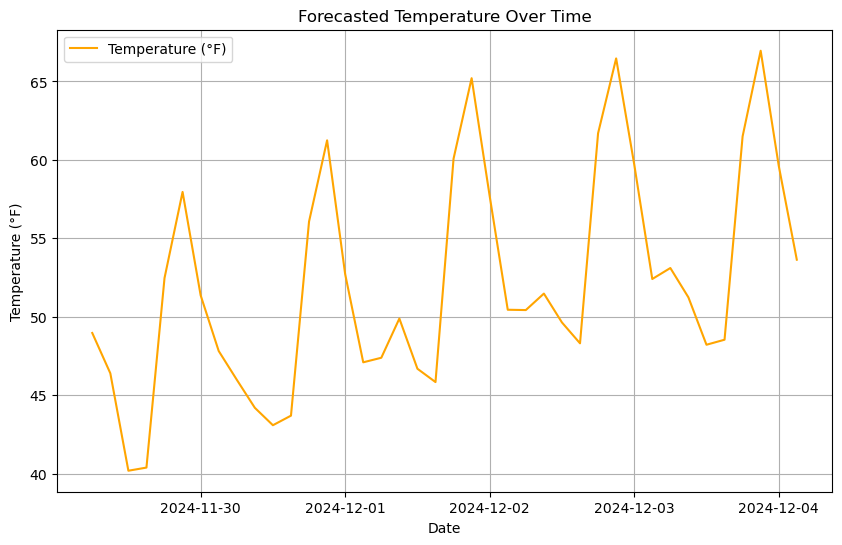

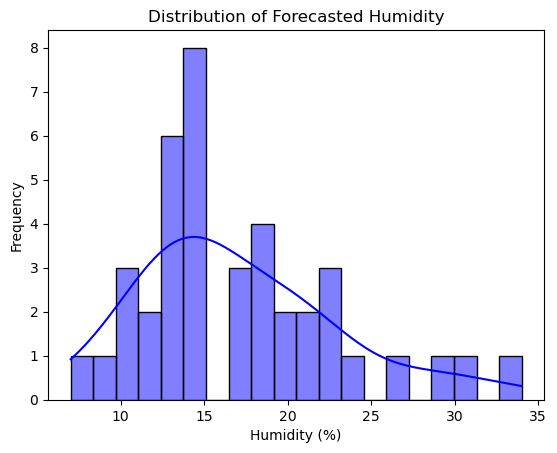

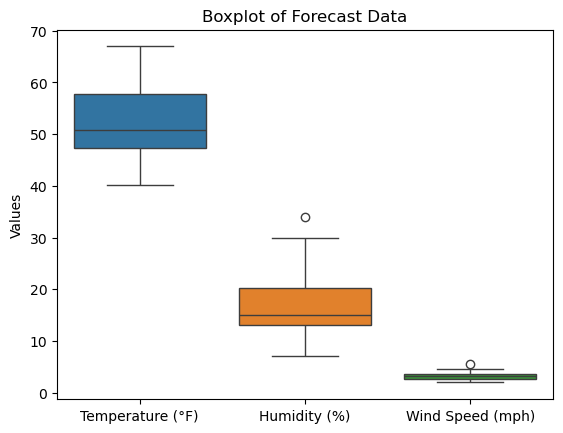


Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit


Please enter menu selection (1 - 4):  3



Summary of Monthly Weather Estimate (Based on 5-Day Forecast):
Average Temperature: 52.15°F
Average Humidity: 17.07%
Average Wind Speed: 3.22 mph
Temperature Range: 40.19°F - 66.96°F
Humidity Range: 7.00% - 34.00%
Wind Speed Range: 1.95 mph - 5.61 mph


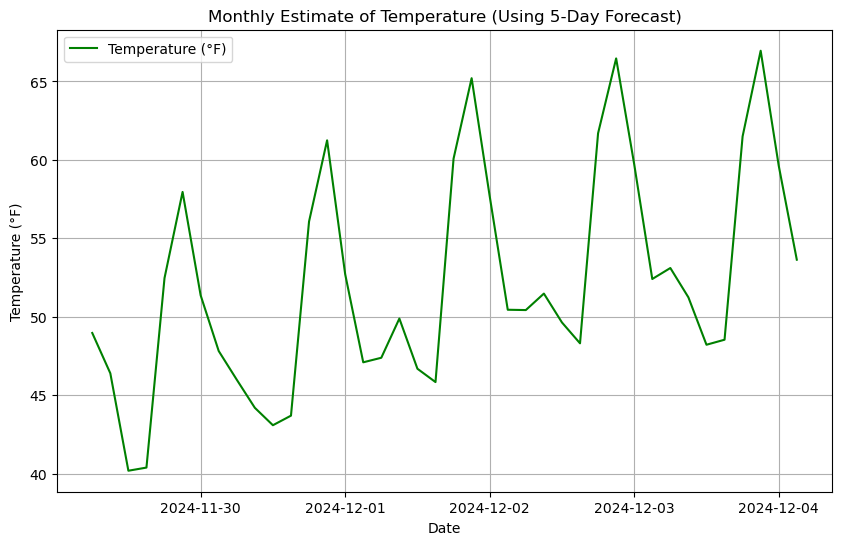

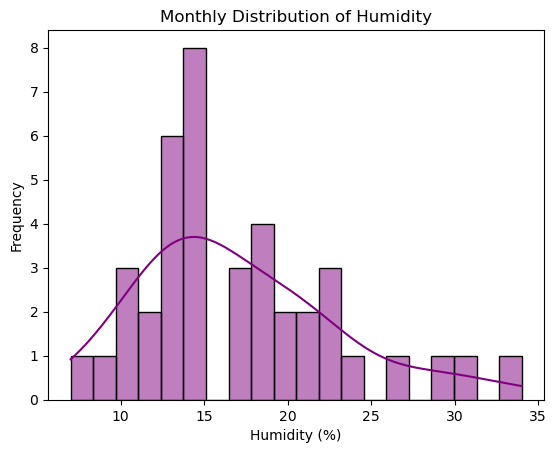

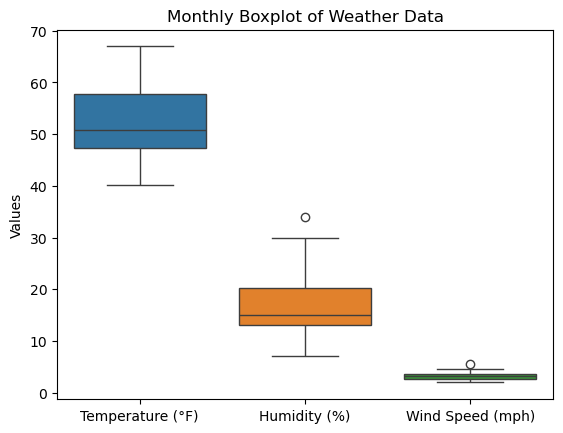


Weather Dashboard Main Menu
1. Current Weather
2. Forecast Weather
3. Monthly Weather
4. Exit


Please enter menu selection (1 - 4):  4


Exiting the Weather Dashboard.


In [15]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Please enter your OpenWeatherMap API Key here
APPID = '3741775b9523fb5654ad764de205b071'

# Assume the location to be Las Vegas, NV, US
location = 'Las Vegas, NV, US'

# Function to get weather data from OpenWeatherMap API
def get_weather_data(endpoint, params):
    url = f'https://api.openweathermap.org/data/2.5/{endpoint}'
    params['q'] = location
    params['appid'] = APPID
    params['units'] = 'Imperial'
    response = requests.get(url, params=params)
    response.raise_for_status()
    return json.loads(response.text)

# Function to display current weather
def display_current_weather():
    weather_data = get_weather_data('weather', {})
    print('Current weather in', weather_data['name'])
    weather_sec = weather_data['weather'][0]['description']
    main_sec = weather_data['main']
    print(f"Description: {weather_sec}")
    print(f"Temperature: {main_sec['temp']}°F")
    print(f"Feels like: {main_sec['feels_like']}°F")
    print(f"Humidity: {main_sec['humidity']}%")

# Function to display and summarize forecast weather
def display_forecast_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    dates = [item['dt_txt'] for item in forecast_data['list']]
    temperatures = [item['main']['temp'] for item in forecast_data['list']]
    humidities = [item['main']['humidity'] for item in forecast_data['list']]
    wind_speeds = [item['wind']['speed'] for item in forecast_data['list']]

    forecast_df = pd.DataFrame({
        'Date': pd.to_datetime(dates),
        'Temperature (°F)': temperatures,
        'Humidity (%)': humidities,
        'Wind Speed (mph)': wind_speeds
    })

    # Summarize the forecast weather
    print("\nSummary of Forecast Weather:")
    print(f"Average Temperature: {forecast_df['Temperature (°F)'].mean():.2f}°F")
    print(f"Average Humidity: {forecast_df['Humidity (%)'].mean():.2f}%")
    print(f"Average Wind Speed: {forecast_df['Wind Speed (mph)'].mean():.2f} mph")
    print(f"Temperature Range: {forecast_df['Temperature (°F)'].min():.2f}°F - {forecast_df['Temperature (°F)'].max():.2f}°F")
    print(f"Humidity Range: {forecast_df['Humidity (%)'].min():.2f}% - {forecast_df['Humidity (%)'].max():.2f}%")
    print(f"Wind Speed Range: {forecast_df['Wind Speed (mph)'].min():.2f} mph - {forecast_df['Wind Speed (mph)'].max():.2f} mph")

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(forecast_df['Date'], forecast_df['Temperature (°F)'], label='Temperature (°F)', color='orange')
    plt.title('Forecasted Temperature Over Time')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid()
    plt.show()

    sns.histplot(forecast_df['Humidity (%)'], kde=True, bins=20, color='blue')
    plt.title('Distribution of Forecasted Humidity')
    plt.xlabel('Humidity (%)')
    plt.ylabel('Frequency')
    plt.show()

    sns.boxplot(data=forecast_df[['Temperature (°F)', 'Humidity (%)', 'Wind Speed (mph)']])
    plt.title('Boxplot of Forecast Data')
    plt.xticks([0, 1, 2], ['Temperature (°F)', 'Humidity (%)', 'Wind Speed (mph)'])
    plt.ylabel('Values')
    plt.show()

# Function to display and summarize monthly weather (using the 5-day forecast as an estimate)
def display_monthly_weather():
    forecast_data = get_weather_data('forecast', {'cnt': 40})  # 5-day forecast
    dates = [item['dt_txt'] for item in forecast_data['list']]
    temperatures = [item['main']['temp'] for item in forecast_data['list']]
    humidities = [item['main']['humidity'] for item in forecast_data['list']]
    wind_speeds = [item['wind']['speed'] for item in forecast_data['list']]

    forecast_df = pd.DataFrame({
        'Date': pd.to_datetime(dates),
        'Temperature (°F)': temperatures,
        'Humidity (%)': humidities,
        'Wind Speed (mph)': wind_speeds
    })

    # Summarize the monthly weather
    avg_temp = forecast_df['Temperature (°F)'].mean()
    avg_humidity = forecast_df['Humidity (%)'].mean()
    avg_wind_speed = forecast_df['Wind Speed (mph)'].mean()

    print("\nSummary of Monthly Weather Estimate (Based on 5-Day Forecast):")
    print(f"Average Temperature: {avg_temp:.2f}°F")
    print(f"Average Humidity: {avg_humidity:.2f}%")
    print(f"Average Wind Speed: {avg_wind_speed:.2f} mph")
    print(f"Temperature Range: {forecast_df['Temperature (°F)'].min():.2f}°F - {forecast_df['Temperature (°F)'].max():.2f}°F")
    print(f"Humidity Range: {forecast_df['Humidity (%)'].min():.2f}% - {forecast_df['Humidity (%)'].max():.2f}%")
    print(f"Wind Speed Range: {forecast_df['Wind Speed (mph)'].min():.2f} mph - {forecast_df['Wind Speed (mph)'].max():.2f} mph")

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(forecast_df['Date'], forecast_df['Temperature (°F)'], label='Temperature (°F)', color='green')
    plt.title('Monthly Estimate of Temperature (Using 5-Day Forecast)')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°F)')
    plt.legend()
    plt.grid()
    plt.show()

    sns.histplot(forecast_df['Humidity (%)'], kde=True, bins=20, color='purple')
    plt.title('Monthly Distribution of Humidity')
    plt.xlabel('Humidity (%)')
    plt.ylabel('Frequency')
    plt.show()

    sns.boxplot(data=forecast_df[['Temperature (°F)', 'Humidity (%)', 'Wind Speed (mph)']])
    plt.title('Monthly Boxplot of Weather Data')
    plt.xticks([0, 1, 2], ['Temperature (°F)', 'Humidity (%)', 'Wind Speed (mph)'])
    plt.ylabel('Values')
    plt.show()

# Main menu function to display options and link to weather dashboard
def main_menu():
    while True:
        print("\nWeather Dashboard Main Menu")
        print("1. Current Weather")
        print("2. Forecast Weather")
        print("3. Monthly Weather")
        print("4. Exit")

        menu_input = input("Please enter menu selection (1 - 4): ")

        if menu_input == "1":
            display_current_weather()
        elif menu_input == "2":
            display_forecast_weather()
        elif menu_input == "3":
            display_monthly_weather()
        elif menu_input == "4":
            print("Exiting the Weather Dashboard.")
            break
        else:
            print("Invalid choice. Please try again.")

# Run the main menu
if __name__ == "__main__":
    main_menu()
